# Notebook to compare performance of RL models

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

random.seed(24)
np.random.seed(24)

---
## Markov Decision Process (MDP) Framework

In [2]:
class GridWorld:
    """
    A simple 4x4 GridWorld MDP.
    State: (row, col). Goal: reach (3,3). Pit: (2,2).
    Actions: 0=Up, 1=Down, 2=Left, 3=Right
    """
    def __init__(self, size=4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.goal = (size-1, size-1)
        self.pit = (size//2, size//2)
        self.action_effects = [(-1,0),(1,0),(0,-1),(0,1)]  # U D L R

    def state_id(self, s): return s[0]*self.size + s[1]
    def state_xy(self, sid): return (sid // self.size, sid % self.size)

    def reset(self):
        self.pos = (0, 0)
        return self.state_id(self.pos)

    def step(self, action):
        dr, dc = self.action_effects[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)
        done = False
        if self.pos == self.goal:
            reward, done = +10.0, True
        elif self.pos == self.pit:
            reward, done = -10.0, True
        else:
            reward = -0.1  # small step penalty encourages efficiency
        return self.state_id(self.pos), reward, done

env = GridWorld()
print(f"GridWorld: {env.n_states} states, {env.n_actions} actions")
print(f"Goal state id: {env.state_id(env.goal)}, Pit state id: {env.state_id(env.pit)}")

GridWorld: 16 states, 4 actions
Goal state id: 15, Pit state id: 10


## Temporal-Difference Learning

The TD update is:

$$V^{\pi,(n+1)}(s) \leftarrow V^{\pi,(n)}(s) + \beta_n(s,a) \underbrace{\bigl[ r + \gamma V^{\pi,(n)}(s') - V^{\pi,(n)}(s) \bigr]}_{\text{TD error } \delta_n}$$

In [3]:
def temporal_dl(env, policy, num_episodes=2000, gamma=0.99, lr=0.1):
    """
    policy: callable(state) to action
    Returns: V (value function array), td_errors (history)
    """
    V = np.zeros(env.n_states)
    td_errors_hist = []

    for _ in range(num_episodes):
        s = env.reset()
        done = False
        ep_td = []
        while not done:
            a = policy(s)
            s_next, r, done = env.step(a)

            # TD error
            td_error = r + gamma * V[s_next] * (1 - done) - V[s]

            # Update rule
            V[s] += lr * td_error
            ep_td.append(abs(td_error))
            s = s_next
        td_errors_hist.append(np.mean(ep_td))

    return V, td_errors_hist

---
## Q-Learning (Off-Policy)

The Q-learning update is:

$$Q^{(n+1)}(s,a) \leftarrow (1-\beta_n)Q^{(n)}(s,a) + \beta_n \left[ r(s,a) + \gamma \max_{a'} Q^{(n)}(s',a') \right]$$

Watkins & Dayan (1992) guarantee convergence when $\sum \beta_n = \infty$ and $\sum \beta_n^2 < \infty$.

In [4]:
def q_learning(env, num_episodes=5000, gamma=0.99, lr=0.1, epsilon=0.1):
    """
    Algorithm 2 (paper): Q-learning with epsilon-greedy exploration.
    Off-policy: uses max_a' Q(s',a') regardless of what action is taken.
    
    Returns: Q table, cumulative rewards per episode
    """
    Q = np.zeros((env.n_states, env.n_actions))
    cum_rewards = []

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        total_r = 0
        while not done:
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                a = np.random.randint(env.n_actions)
            else:
                a = np.argmax(Q[s])
            
            s_next, r, done = env.step(a)
            total_r += r
            
            # Q-learning update (Eq. 2.23)
            target = r + gamma * np.max(Q[s_next]) * (1 - done)
            Q[s, a] += lr * (target - Q[s, a])
            s = s_next

        cum_rewards.append(total_r)

    return Q, cum_rewards

---
## SARSA (On-Policy TD Control)

SARSA differs from Q-learning in the update target. It uses the *next action actually taken* rather than the greedy max:

$$Q^{(n+1)}(s,a) \leftarrow (1-\beta)Q^{(n)}(s,a) + \beta \left(r + \gamma Q^{(n)}(s', a')\right)$$

where $a'$ is chosen by the $\varepsilon$-greedy policy

In [5]:
def sarsa(env, num_episodes=5000, gamma=0.99, lr=0.1, epsilon=0.1):
    """
    Algorithm 3 (paper): SARSA - On-policy TD Control.
    Uses (s, a, r, s', a') tuples - hence 'SARSA'.
    Key difference from Q-learning: next action a' is drawn from the *same* epsilon-greedy policy,
    not from the greedy (max) policy.
    """
    Q = np.zeros((env.n_states, env.n_actions))
    cum_rewards = []

    def eps_greedy(s):
        if np.random.rand() < epsilon:
            return np.random.randint(env.n_actions)
        return np.argmax(Q[s])

    for ep in range(num_episodes):
        s = env.reset()
        a = eps_greedy(s)    # Choose initial action using policy derived from Q^(0)
        done = False
        total_r = 0

        while not done:
            s_next, r, done = env.step(a)
            total_r += r
            a_next = eps_greedy(s_next)   # Next action from same eps-greedy policy

            # SARSA update (Eq. 2.25)
            target = r + gamma * Q[s_next, a_next] * (1 - done)
            Q[s, a] += lr * (target - Q[s, a])

            s, a = s_next, a_next

        cum_rewards.append(total_r)

    return Q, cum_rewards

---
## Deep Q-Network (DQN)

DQN extends Q-learning to large/continuous state spaces using:
1. **Neural network** to approximate $Q(s,a;\theta)$
2. **Experience replay buffer** $\mathcal{B}$ to break temporal correlations
3. **Target network** $Q(\cdot;\theta^-)$ updated every $T_\text{target}$ steps

Loss:
$$L_\text{DQN}(\theta, \theta^-) = \frac{1}{B} \sum_{i=1}^B \bigl\| Q(s_i,a_i;\theta) - \tilde{Y}_i^Q \bigr\|_2^2,
\quad \tilde{Y}_i^Q = r_i + \gamma \max_{a'} Q(s'_i,a';\theta^-)$$

In [6]:

class QNetwork(nn.Module):
    """Fully-connected Q-network: state -> Q-values for all actions"""
    def __init__(self, n_states, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x): return self.net(x)


class ReplayBuffer:
    """Experience replay buffer B"""
    def __init__(self, capacity=10000):
        self.buf = deque(maxlen=capacity)
    def push(self, s, a, r, s_next, done):
        self.buf.append((s, a, r, s_next, done))
    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s_next, done = zip(*batch)
        # Handle both int actions (DQN) and float actions (DDPG)
        try:
            a_t = torch.LongTensor(list(a))
        except (TypeError, ValueError):
            a_t = torch.FloatTensor(np.array(list(a), dtype=np.float32))
        return (torch.FloatTensor(np.array(list(s), dtype=np.float32)),
                a_t,
                torch.FloatTensor(np.array(list(r), dtype=np.float32)),
                torch.FloatTensor(np.array(list(s_next), dtype=np.float32)),
                torch.FloatTensor(np.array(list(done), dtype=np.float32)))
    def __len__(self): return len(self.buf)


def dqn(env, num_episodes=1000, gamma=0.99, lr=1e-3, batch_size=64, buffer_capacity=10000,
        epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995, target_update_freq=20):
    """
    Deep Q-Network (DQN),
    Uses experience replay + target network for stable training.
    State is one-hot encoded for the tabular GridWorld environment.
    """
    n_s, n_a = env.n_states, env.n_actions

    q_net = QNetwork(n_s, n_a)
    tgt_net = QNetwork(n_s, n_a) # Target network theta^-
    tgt_net.load_state_dict(q_net.state_dict())
    tgt_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    replay = ReplayBuffer(buffer_capacity)

    epsilon = epsilon_start
    cum_rewards = []

    def encode(s):
        """One-hot state encoding"""
        v = np.zeros(n_s)
        v[s] = 1.0
        return v

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        total_r = 0

        while not done:
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                a = np.random.randint(n_a)
            else:
                with torch.no_grad():
                    q_vals = q_net(torch.FloatTensor(encode(s)))
                a = q_vals.argmax().item()

            s_next, r, done = env.step(a)
            total_r += r
            replay.push(encode(s), a, r, encode(s_next), float(done))
            s = s_next

            # Train when replay buffer has enough samples
            if len(replay) >= batch_size:
                s_b, a_b, r_b, sn_b, d_b = replay.sample(batch_size)

                # Current Q-values
                q_curr = q_net(s_b).gather(1, a_b.unsqueeze(1)).squeeze()

                # Target Q-values (using frozen target network)
                with torch.no_grad():
                    q_tgt = r_b + gamma * tgt_net(sn_b).max(1)[0] * (1 - d_b)

                # DQN loss
                loss = nn.MSELoss()(q_curr, q_tgt)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Update target network every T_target episodes
        if ep % target_update_freq == 0:
            tgt_net.load_state_dict(q_net.state_dict())

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        cum_rewards.append(total_r)

    return q_net, cum_rewards

---
## Reinforce: Monte Carlo Policy Gradient

From the **Policy Gradient Theorem**,

$$\nabla_\theta J(\theta) = \mathbb{E}_{s \sim \mu^{\pi_\theta},\, a \sim \pi_\theta} \bigl[\nabla_\theta \ln \pi(s,a;\theta) \cdot Q^{\pi_\theta}(s,a)\bigr]$$

REINFORCE approximates $Q$ with the Monte Carlo return $G_t = \sum_{s=t+1}^M \gamma^{s-t-1} r_s$

In [ ]:
class SoftmaxPolicy:
    """
    Tabular softmax policy: pi(a|s; theta) = exp(theta[s,a]) / sum_a' exp(theta[s,a'])
    This parametrizes pi differentiably, as required by the policy gradient theorem.
    """
    def __init__(self, n_states, n_actions, temperature=1.0):
        self.theta = np.zeros((n_states, n_actions))
        self.tau = temperature

    def probs(self, s):
        logits = self.theta[s] / self.tau
        logits -= logits.max()   # numerical stability
        exp_l = np.exp(logits)
        return exp_l / exp_l.sum()

    def select_action(self, s):
        return np.random.choice(len(self.theta[s]), p=self.probs(s))

    def log_grad(self, s, a):
        """Gradient of log pi(a|s) w.r.t. theta[s,:] (one-hot minus probs)"""
        p = self.probs(s)
        grad = -p.copy()
        grad[a] += 1.0
        return grad


def reinforce(env, num_episodes=5000, gamma=0.99, lr=0.01):
    """
    REINFORCE — Monte Carlo Policy Gradient.
    
    Updates theta using the full-trajectory return G_t:
      theta <- theta + beta * gamma^t * G_t * grad_theta log pi(s_t, a_t; theta)
    """
    policy = SoftmaxPolicy(env.n_states, env.n_actions)
    cum_rewards = []

    for ep in range(num_episodes):
        # 1. Collect full trajectory
        trajectory = []  # (s, a, r)
        s = env.reset()
        done = False
        while not done:
            a = policy.select_action(s)
            s_next, r, done = env.step(a)
            trajectory.append((s, a, r))
            s = s_next

        cum_rewards.append(sum(x[2] for x in trajectory))

        # 2. Compute returns G_t (discounted sum of future rewards)
        M = len(trajectory)
        G = np.zeros(M)
        G[-1] = trajectory[-1][2]
        for t in range(M-2, -1, -1):
            G[t] = trajectory[t][2] + gamma*G[t+1]

        # 3. Policy gradient update (Eq. 2.29)
        for t, (s, a, _) in enumerate(trajectory):
            policy.theta[s] += lr *(gamma**t)*G[t]*policy.log_grad(s, a)

    return policy, cum_rewards

---
## Actor-Critic

The Actor-Critic method maintains two networks:
- **Critic**: estimates $Q(s,a;w) = \phi(s,a)^\top w$ using TD(0)
- **Actor**: updates policy parameter $\theta$ using the critic's estimate

$$w^{(n+1)} \leftarrow w^{(n)} + \beta_w \, \delta \, \phi(s,a)$$
$$\theta^{(n+1)} \leftarrow \theta^{(n)} + \beta_\theta \, Q(s,a;w^{(n)}) \, \nabla_\theta \ln \pi(s,a;\theta^{(n)})$$

In [8]:
def actor_critic(env, num_episodes=5000, gamma=0.99, lr_actor=0.01, lr_critic=0.05):
    """
    Algorithm 5 (paper): Actor-Critic.
    Critic: linear function approximation Q(s,a;w) = phi(s,a)^T w
    Actor: softmax policy parametrized by theta
    Single-scale setting: actor and critic update simultaneously.
    """
    n_s, n_a = env.n_states, env.n_actions
    # Feature vector: one-hot encoding of (state, action) pair
    n_features = n_s * n_a

    def phi(s, a):
        """State-action feature vector (one-hot)."""
        feat = np.zeros(n_features)
        feat[s * n_a + a] = 1.0
        return feat

    w = np.zeros(n_features)  # Critic parameters
    policy = SoftmaxPolicy(n_s, n_a) # Actor parameters (theta)
    cum_rewards = []

    for ep in range(num_episodes):
        s = env.reset()
        a = policy.select_action(s)
        done = False
        total_r = 0

        while not done:
            s_next, r, done = env.step(a)
            total_r += r
            a_next = policy.select_action(s_next)

            # Critic update: TD error (line 8 in Algorithm 5)
            Q_sa  = phi(s, a).dot(w)
            Q_next = phi(s_next, a_next).dot(w) * (1 - done)
            delta = r + gamma * Q_next - Q_sa   # TD error
            w += lr_critic * delta * phi(s, a)  # w^(n+1) (line 9)

            # Actor update: policy gradient (line 10)
            policy.theta[s] += lr_actor * Q_sa * policy.log_grad(s, a)

            s, a = s_next, a_next

        cum_rewards.append(total_r)

    return policy, w, cum_rewards

## Comparision

Algorithm            Type                       Final Reward
----------------------------------------------------------------------
Q-Learning           Value-based, off-policy        8.438
SARSA                Value-based, on-policy        8.663
REINFORCE            Policy-based (MC PG)        9.450
Actor-Critic         Policy & Value hybrid        9.491


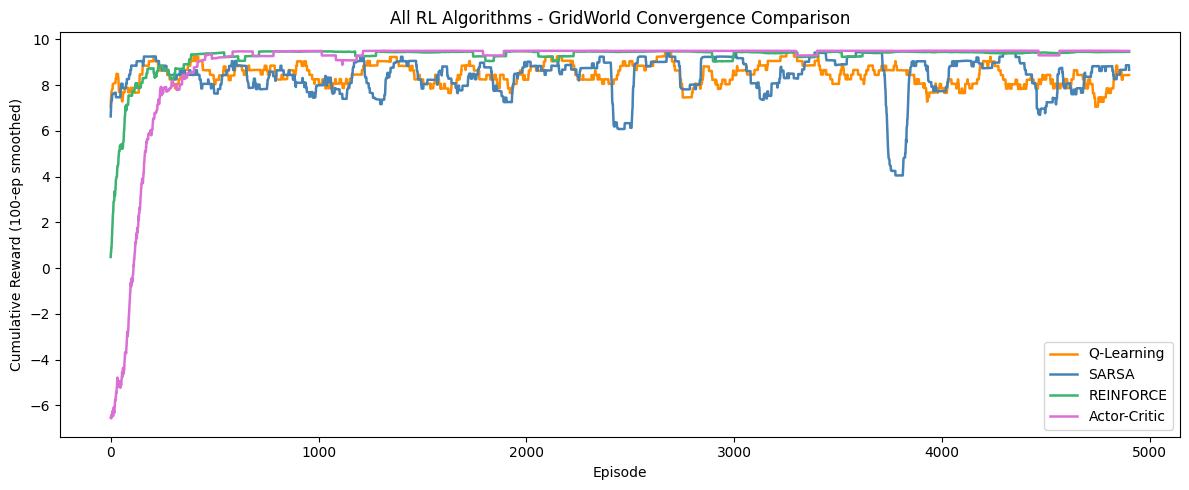

In [9]:
_, rewards_ql = q_learning(env, num_episodes=5000)
_, rewards_sarsa = sarsa(env, num_episodes=5000)
_, rewards_rf = reinforce(env, num_episodes=5000)
_, _, rewards_ac = actor_critic(env, num_episodes=5000)


# Final comparison table
print(f"{'Algorithm':<20} {'Type':<20} {'Final Reward':>18}")
print("-" * 70)

results = [
    ('Q-Learning', 'Value-based, off-policy', rewards_ql),
    ('SARSA', 'Value-based, on-policy', rewards_sarsa),
    ('REINFORCE', 'Policy-based (MC PG)', rewards_rf),
    ('Actor-Critic', 'Policy & Value hybrid', rewards_ac),
]

for name, typ, rews in results:
    final_smooth = np.convolve(rews, np.ones(100)/100, mode='valid')[-1]
    print(f"{name:<20} {typ:<20} {final_smooth:>12.3f}")

# Final convergence plot
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['darkorange','steelblue','mediumseagreen','orchid']
for (name, _, rews), col in zip(results, colors):
    smooth = np.convolve(rews, np.ones(100)/100, mode='valid')
    ax.plot(smooth, label=name, color=col, linewidth=1.8)

ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward (100-ep smoothed)')
ax.set_title('All RL Algorithms - GridWorld Convergence Comparison')
ax.legend()
plt.tight_layout()
plt.show()